### Importy

In [1]:
from time import perf_counter                                                                                             
import pandas as pd                                                                                                       
import numpy as np                                                                                                        
import matplotlib.pyplot as plt                                                                                           
import seaborn as sns                                                                                                     
                                                                                                                              
from sklearn.cluster import KMeans, AgglomerativeClustering                                                               
from sklearn.metrics import silhouette_score                                                                              
from sklearn.metrics.cluster import contingency_matrix                                                                    
                                                                               
def purity_score(labels_true, labels_pred):                                                                               
    cont_matrix = contingency_matrix(labels_true, labels_pred)                                                            
    max_per_cluster = np.max(cont_matrix, axis=0)                                                                         
    return np.sum(max_per_cluster) / np.sum(cont_matrix)                                                                  
                                                                                                                              
                                                                       
df = pd.read_csv('Dry_Bean_preprocessed.csv')                                                                             
X = df.drop(columns=['Class'])                                                                                            
y = df['Class']                                                                                                           

### Model Agglomerative 

In [4]:
silhouette_res = []
purity_res = []

for k in range(2,12):
    model = AgglomerativeClustering(n_clusters = k , metric = 'euclidean', linkage = 'ward')
    model.fit(X)
    initial_clusters = model.labels_
    sil = silhouette_score(X, initial_clusters)
    pure = purity_score(y, initial_clusters)
    silhouette_res.append(sil)
    purity_res.append(pure)


###  Wizualizacja wyników 

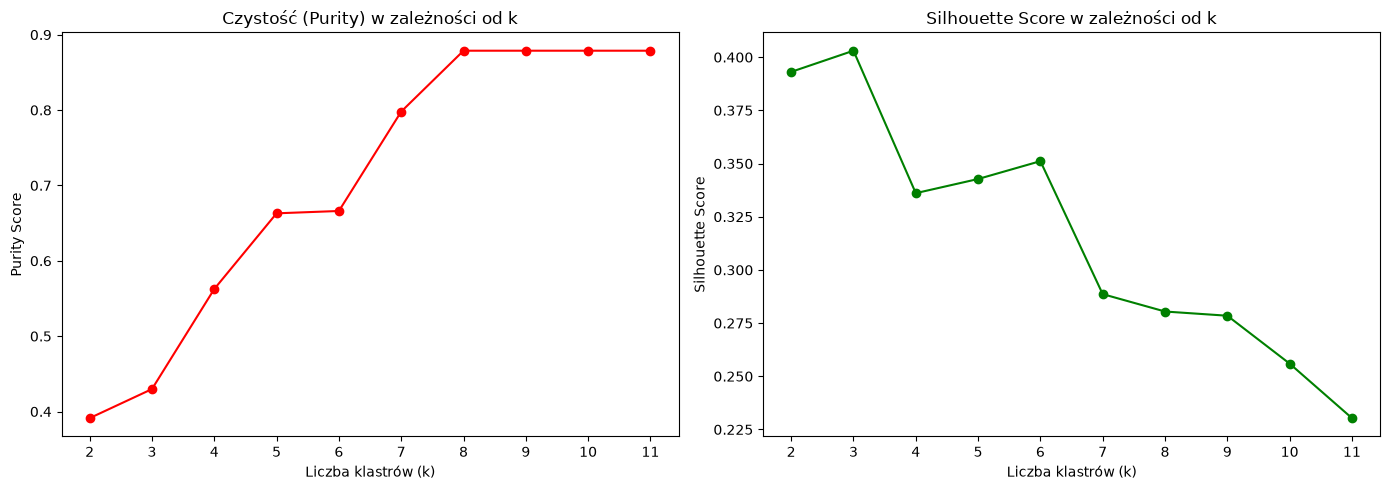

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))                                                                                                                                                                    
                                                                                                                                                                                                      
axes[1].plot(range(2,12), silhouette_res, marker='o', linestyle='-', color='g')                                           
axes[1].set_title('Silhouette Score w zależności od k')                                                                   
axes[1].set_xlabel('Liczba klastrów (k)')                                                                                 
axes[1].set_ylabel('Silhouette Score')                                                                                    
axes[1].set_xticks(range(2,12))                                                                                              
                                                                                                                                                                                                      
axes[0].plot(range(2,12), purity_res, marker='o', linestyle='-', color='r')                                               
axes[0].set_title('Czystość (Purity) w zależności od k')                                                                  
axes[0].set_xlabel('Liczba klastrów (k)')                                                                                 
axes[0].set_ylabel('Purity Score')                                                                                        
axes[0].set_xticks(range(2,12))                                                                                              
                                                                                                                                                                                         
plt.tight_layout()                                                                                                        
plt.show()         

- Najwyższe purity występuje od k = 7 do 11 i jest ono stabline.
- W wykresie Silhouette Score, najwyżej jest k = 3, potem k = 6.
- Jako kompromis wybieram k = 6, ponieważ ma ok purity, a w dodaktu silhouette score jest wysoko.

### Wizualizacja dla k = 6

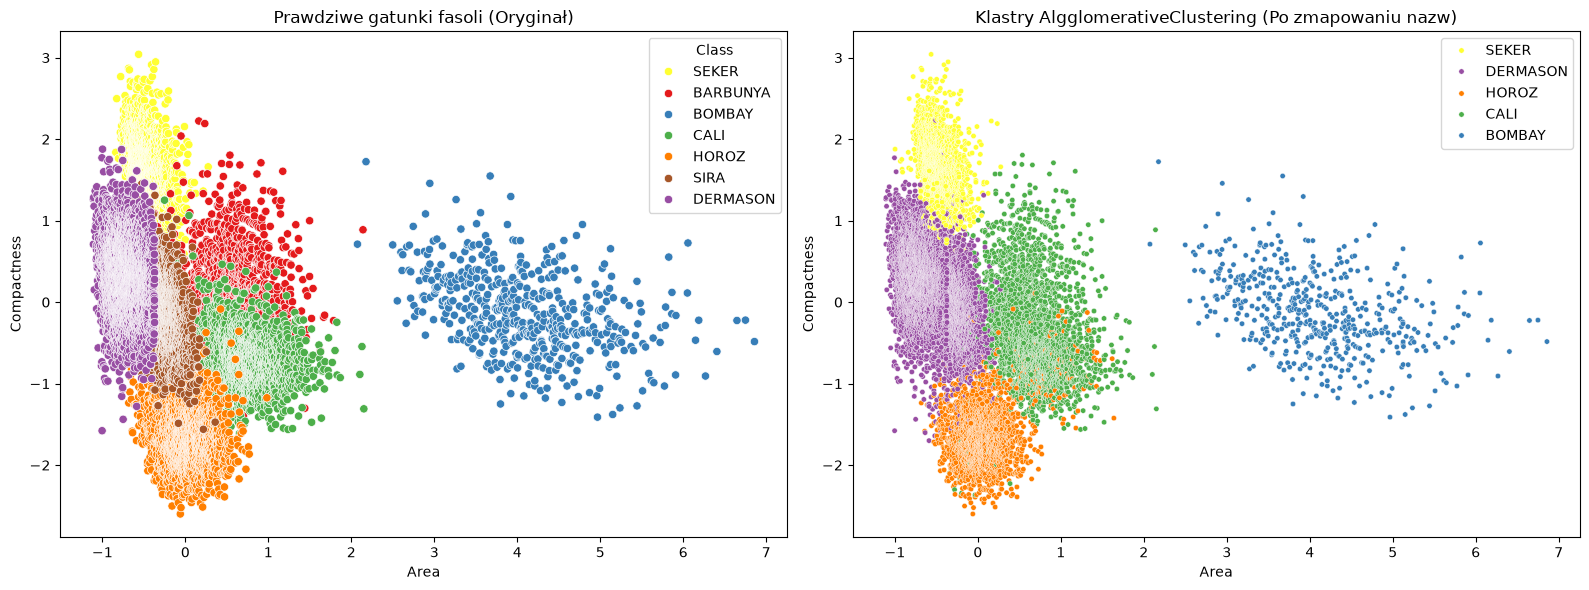

In [12]:
final_agglo = AgglomerativeClustering(n_clusters =6)
final_agglo.fit(X)
predicted_clusters = final_agglo.labels_

mapped_labels = np.empty_like(predicted_clusters, dtype=object)                                                           
for i in range(6):                                                                                                        
    mask = (predicted_clusters == i)                                                                                                                                                 
    common_class = df.loc[mask, 'Class'].mode()[0]                                                                                                                                                  
    mapped_labels[mask] = common_class                                                                              
                                                                                                                                                                                                 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))                                                                           
                                                                                                                                                        
unique_classes = sorted(df['Class'].unique())                                                                             
common_pallette = dict(zip(unique_classes, sns.color_palette("Set1", len(unique_classes))))                                
                                                                                                                                                                                                     
sns.scatterplot(data=df, x='Area', y='Compactness', hue='Class', palette=common_pallette, ax=axes[0])                                                                 
axes[0].set_title('Prawdziwe gatunki fasoli (Oryginał)')                                                                  
sns.scatterplot(data=df, x='Area', y='Compactness', hue=mapped_labels, palette=common_pallette, ax=axes[1], s=15)                                                                 
axes[1].set_title('Klastry AlgglomerativeClustering (Po zmapowaniu nazw)')                                                                 
                                                                                                                              
plt.tight_layout()                                                                                                        
plt.show()   

- K = 6 to optimum, co znaczy, że dwie klasy są bardzo do siebie podobne i stworzą klaster.
- Na wykresie widać , że klasa fioletowa pochłonęła klasę brazową, a zielona czerwoną. To znaczy, że jest jeszcze jedna para klas, które są do siebie bardzo podobne.

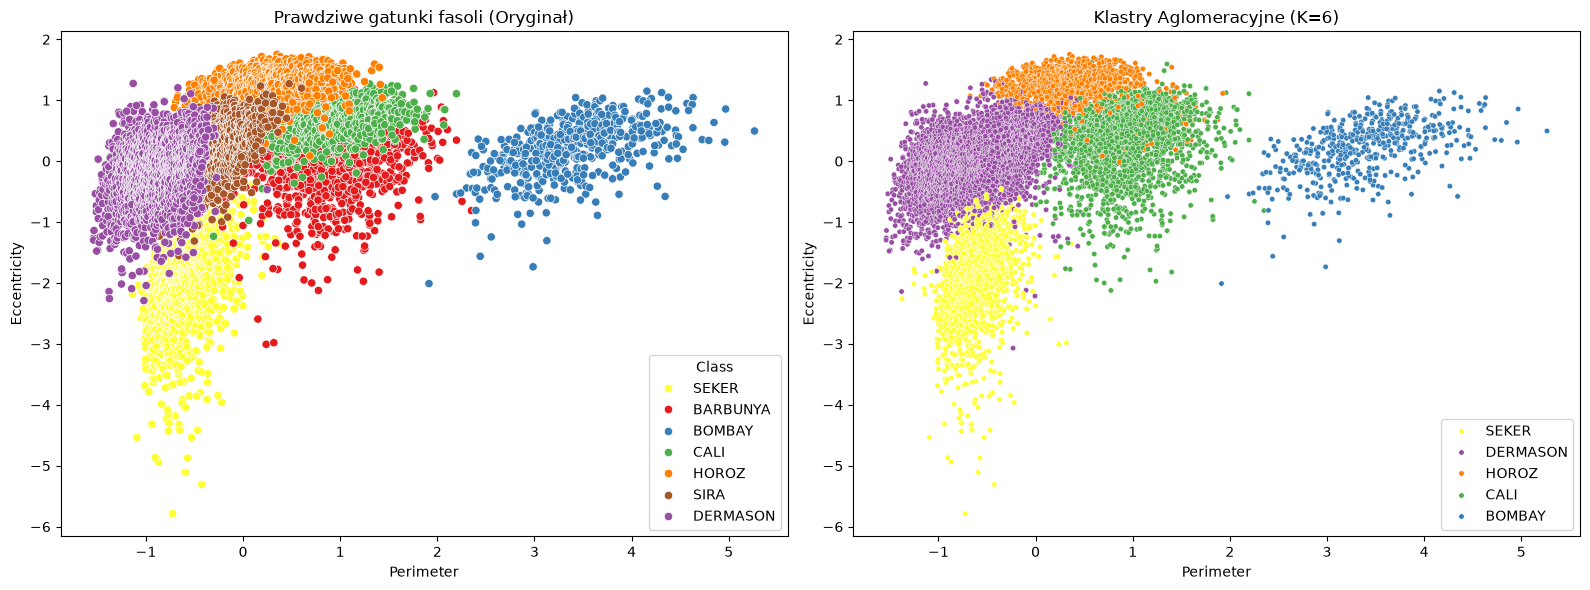

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))                                                                                                         
                                                                                                                                                                                                     
sns.scatterplot(data=df, x='Perimeter', y='Eccentricity', hue='Class', palette=common_pallette, ax=axes[0])                                                                 
axes[0].set_title('Prawdziwe gatunki fasoli (Oryginał)')                                                                  
sns.scatterplot(data=df, x='Perimeter', y='Eccentricity', hue=mapped_labels, palette=common_pallette, ax=axes[1], s=15)                                                                 
axes[1].set_title('Klastry Aglomeracyjne (K=6)')                                                                 
                                                                                                                              
plt.tight_layout()                                                                                                        
plt.show()    

- Stała się analogiczna sytuacja. 

### Pomiar czasu

In [15]:
kmeans_timer = KMeans(n_clusters=7, random_state=67)                                                                      
agglo_timer = AgglomerativeClustering(n_clusters=7, metric='euclidean', linkage='ward')                                   
                                                                                                                              
start_km = perf_counter()                                                                                                 
kmeans_timer.fit(X)                                                                                                       
end_km = perf_counter()                                                                                                   
time_kmeans = end_km - start_km                                                                                           
                                                                                                                                                                                                      
start_agg = perf_counter()                                                                                                
agglo_timer.fit(X)                                                                                                        
end_agg = perf_counter()                                                                                                  
time_agglo = end_agg - start_agg                                                                                          
                                                                                                                                                                                                                                 
print(f"Czas działania K-Means: {time_kmeans:.4f} sekundy")                                                               
print(f"Czas działania Aglomeracyjnej: {time_agglo:.4f} sekundy")                                                         
print(f"K-Means był {(time_agglo / time_kmeans):.1f} razy szybszy!")                                                      

Czas działania K-Means: 0.0262 sekundy
Czas działania Aglomeracyjnej: 2.6993 sekundy
K-Means był 103.0 razy szybszy!


- K-Means był około 100 razy szybszy.

**K-Means** posiada złożoność liniową w stosunku do liczby punktów (szybko przelicza odległości tylko od paru          
centroidów i aktualizuje ich pozycje). Dla 13 tysięcy wierszy radzi sobie z tym w ułamek sekundy.                           
**Klasteryzacja Aglomeracyjna** posiada wysoką złożoność rzędu O(N2 log N) lub O(N3). Algorytm ten na samym początku   
musi policzyć odległości każdego punktu z każdym innym punktem, co tworzy gigantyczną macierz odległości. Przy 13 000   
ziaren daje to dziesiątki milionów operacji matematycznych jeszcze przed startem właściwego łączenia klastrów